In [16]:
!pip install opencv-python scikit-image seaborn tqdm -q

In [17]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from skimage.feature import hog, local_binary_pattern
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, roc_auc_score, roc_curve)

print("✅ All libraries imported")

✅ All libraries imported


In [18]:
!unzip -q real.zip -d /content/real
!unzip -q fake.zip -d /content/fake
print("✅ Datasets extracted")

✅ Datasets extracted


In [19]:
IMG_SIZE = 64  # smaller = faster, still accurate

def extract_features(img_path):
    img = cv2.imread(img_path)
    if img is None:
        return None

    img  = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    rgb  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # 1. HOG — edge/shape patterns
    hog_feats = hog(gray, orientations=8,
                    pixels_per_cell=(8, 8),
                    cells_per_block=(2, 2),
                    feature_vector=True)

    # 2. LBP — texture patterns
    lbp = local_binary_pattern(gray, P=8, R=1, method='uniform')
    lbp_hist, _ = np.histogram(lbp.ravel(), bins=10,
                               range=(0, 10), density=True)

    # 3. FFT — frequency artifacts
    fft       = np.fft.fft2(gray)
    magnitude = np.log1p(np.abs(np.fft.fftshift(fft)))
    h, w      = magnitude.shape
    cy, cx    = h // 2, w // 2
    fft_feats = []
    for r in range(1, 6):
        ring = magnitude[cy-r*6:cy+r*6, cx-r*6:cx+r*6]
        fft_feats += [ring.mean(), ring.std()]
    fft_feats = np.array(fft_feats)

    # 4. Color stats
    stats = np.array([
        gray.mean(), gray.std(),
        np.percentile(gray, 25), np.percentile(gray, 75),
        rgb[:,:,0].mean(), rgb[:,:,1].mean(), rgb[:,:,2].mean()
    ])

    return np.concatenate([hog_feats, lbp_hist, fft_feats, stats])


def load_dataset(folder, label, desc):
    X, y, paths = [], [], []
    all_files = []
    for root, _, files in os.walk(folder):
        for f in files:
            if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
                all_files.append(os.path.join(root, f))

    for path in tqdm(all_files, desc=desc):
        feats = extract_features(path)
        if feats is not None:
            X.append(feats)
            y.append(label)
            paths.append(path)
    return X, y, paths


X_real, y_real, real_paths = load_dataset("/content/real", 0, "🟢 Real")
X_fake, y_fake, fake_paths = load_dataset("/content/fake", 1, "🔴 Fake")

X        = np.array(X_real + X_fake)
y        = np.array(y_real + y_fake)
all_paths = real_paths + fake_paths

print(f"\n✅ Loaded {len(y)} images | Features per image: {X.shape[1]}")
print(f"   Real: {len(y_real)} | Fake: {len(y_fake)}")

🔴 Fake: 100%|██████████| 300/300 [00:04<00:00, 72.06it/s]


✅ Loaded 800 images | Features per image: 1595
   Real: 500 | Fake: 300


In [20]:
print(f"Before PCA: {X.shape[1]} features")

pre_scaler = StandardScaler()
X_scaled   = pre_scaler.fit_transform(X)

pca = PCA(n_components=150, random_state=42)
X   = pca.fit_transform(X_scaled)

print(f"After PCA : {X.shape[1]} features")
print(f"Variance retained: {pca.explained_variance_ratio_.sum()*100:.1f}%")
print("✅ PCA Done")

Before PCA: 1595 features
After PCA : 150 features
Variance retained: 77.8%
✅ PCA Done


In [21]:
X_train, X_test, y_train, y_test, paths_train, paths_test = train_test_split(
    X, y, all_paths,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)

model = VotingClassifier(
    estimators=[('rf', rf), ('gb', gb)],
    voting='soft',
    n_jobs=-1
)

print("⏳ Training... (under 1 min)")
model.fit(X_train, y_train)
print("✅ Model Training Complete!")

⏳ Training... (under 1 min)
✅ Model Training Complete!


  🎯 Accuracy  : 62.50%
  📈 ROC-AUC   : 0.4142
  📌 Threshold : inf
              precision    recall  f1-score   support

        Real       0.62      1.00      0.77       100
        Fake       0.00      0.00      0.00        60

    accuracy                           0.62       160
   macro avg       0.31      0.50      0.38       160
weighted avg       0.39      0.62      0.48       160



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/seaborn/u

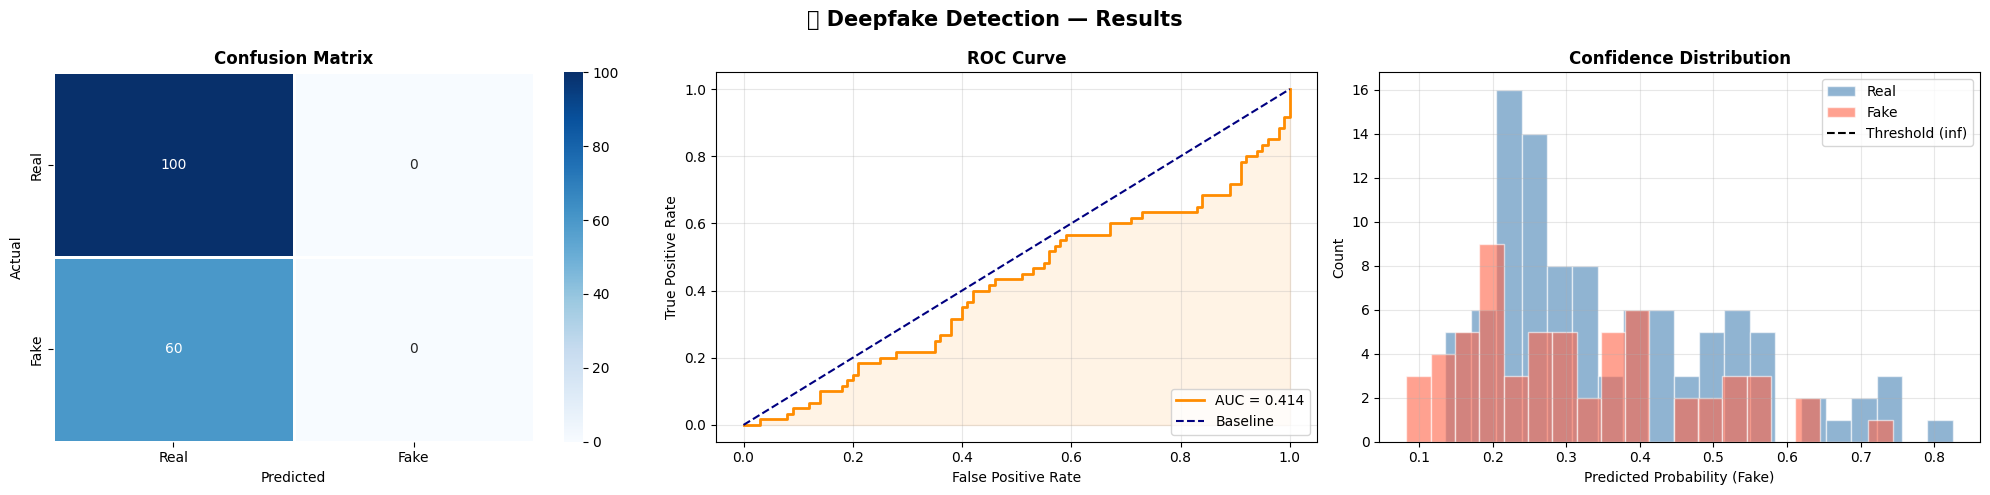

In [22]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Best threshold
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
best_thresh  = thresholds[np.argmax(tpr - fpr)]
y_pred_best  = (y_prob >= best_thresh).astype(int)

accuracy  = accuracy_score(y_test, y_pred_best)
auc_score = roc_auc_score(y_test, y_prob)

print("=" * 45)
print(f"  🎯 Accuracy  : {accuracy * 100:.2f}%")
print(f"  📈 ROC-AUC   : {auc_score:.4f}")
print(f"  📌 Threshold : {best_thresh:.3f}")
print("=" * 45)
print(classification_report(y_test, y_pred_best,
                            target_names=["Real", "Fake"]))

# Plots
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle("🔍 Deepfake Detection — Results",
             fontsize=15, fontweight='bold')

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real','Fake'],
            yticklabels=['Real','Fake'],
            ax=axes[0], linewidths=1, linecolor='white')
axes[0].set_title("Confusion Matrix", fontweight='bold')
axes[0].set_ylabel("Actual")
axes[0].set_xlabel("Predicted")

# ROC Curve
axes[1].plot(fpr, tpr, color='darkorange', lw=2,
             label=f'AUC = {auc_score:.3f}')
axes[1].plot([0,1],[0,1],'navy',lw=1.5,linestyle='--',label='Baseline')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='darkorange')
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve", fontweight='bold')
axes[1].legend(loc="lower right")
axes[1].grid(alpha=0.3)

# Confidence Distribution
axes[2].hist(y_prob[y_test==0], bins=20, alpha=0.6,
             color='steelblue', label='Real', edgecolor='white')
axes[2].hist(y_prob[y_test==1], bins=20, alpha=0.6,
             color='tomato', label='Fake', edgecolor='white')
axes[2].axvline(best_thresh, color='black', linestyle='--',
                lw=1.5, label=f'Threshold ({best_thresh:.2f})')
axes[2].set_xlabel("Predicted Probability (Fake)")
axes[2].set_ylabel("Count")
axes[2].set_title("Confidence Distribution", fontweight='bold')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("evaluation.png", dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_11666/4052133928.py:28: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11666/4052133928.py:28: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11666/4052133928.py:28: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11666/4052133928.py:29: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig("predictions.png", dpi=150, bbox_inches='tight')
/tmp/ipykernel_11666/4052133928.py:29: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig("predictions.png", dpi=150, bbox_inches='tight')
/tmp/ipykernel_11666/4052133928.py:29: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  plt.savefig("predictions.png", dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPyt

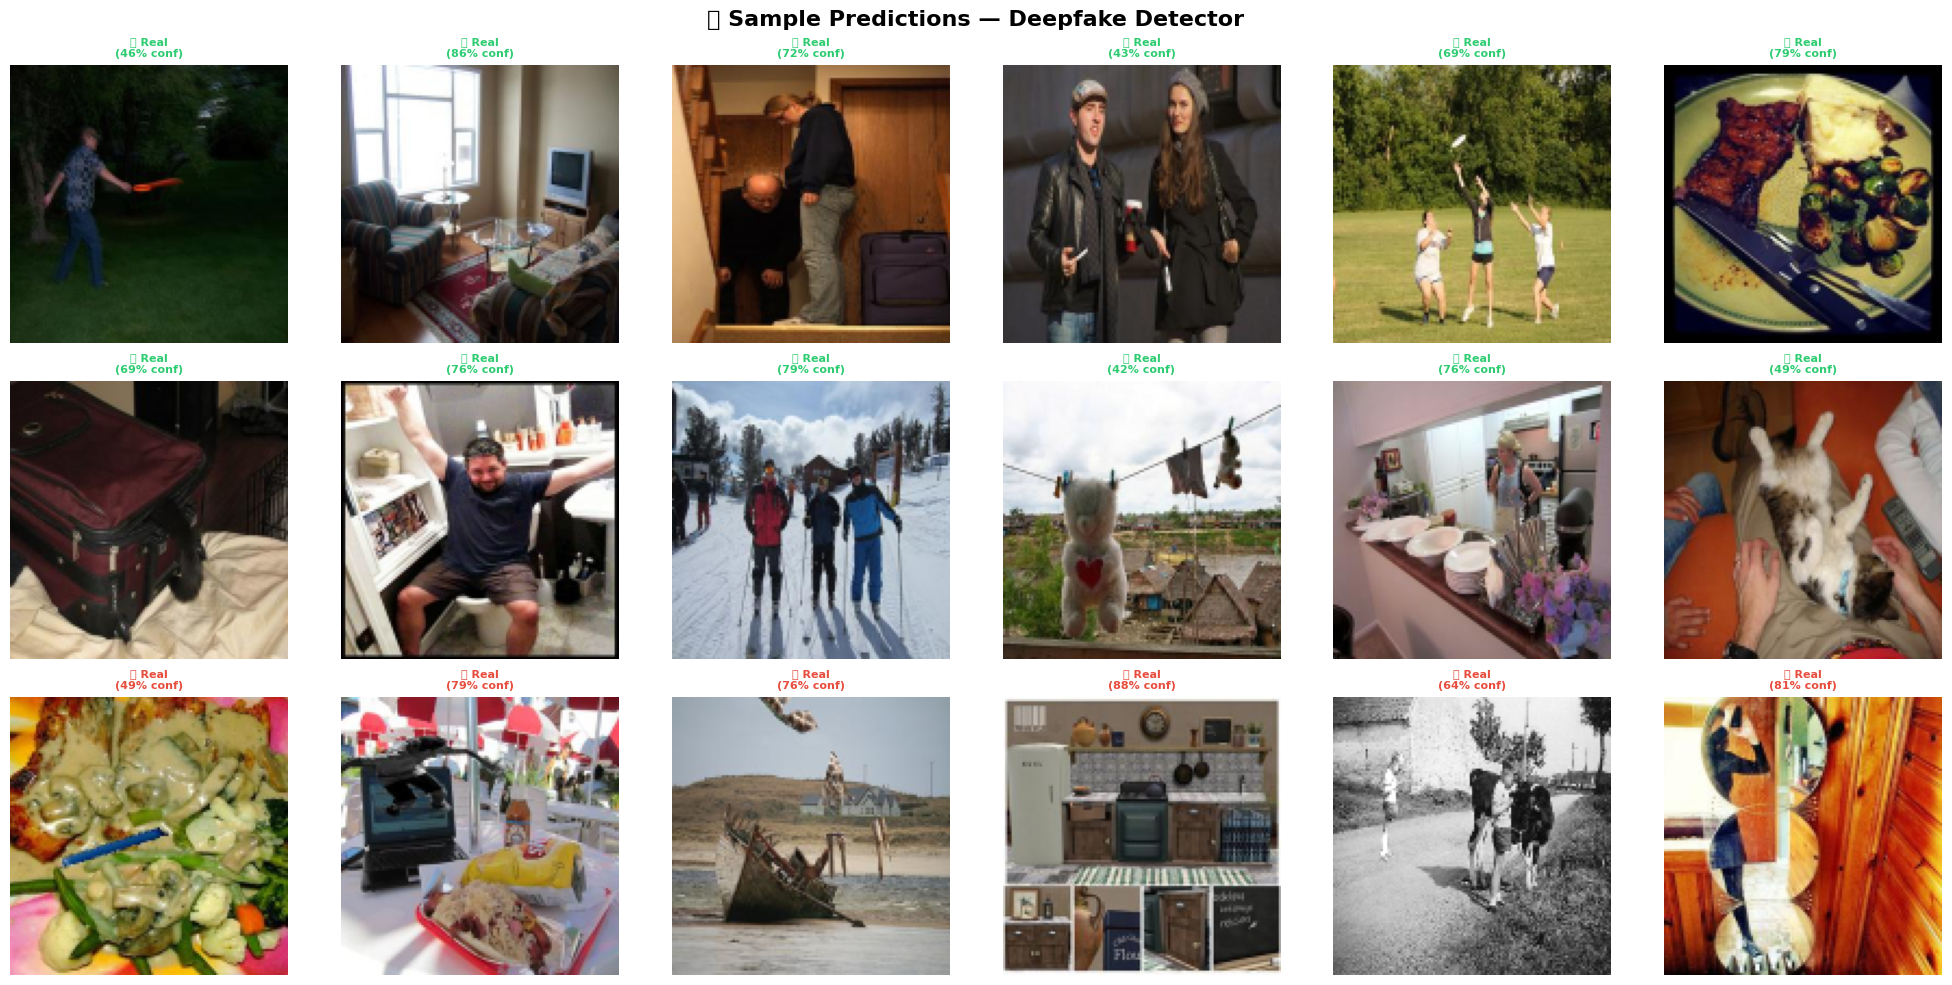

In [23]:
fig, axes = plt.subplots(3, 6, figsize=(20, 10))
fig.suptitle("🧠 Sample Predictions — Deepfake Detector",
             fontsize=16, fontweight='bold')

correct_idx   = np.where(y_pred_best == y_test)[0][:12]
incorrect_idx = np.where(y_pred_best != y_test)[0][:6]
sample_idx    = list(correct_idx[:12]) + list(incorrect_idx[:6])

for i, idx in enumerate(sample_idx[:18]):
    row, col = divmod(i, 6)
    ax = axes[row][col]

    img = cv2.imread(paths_test[idx])
    img = cv2.resize(img, (128, 128))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    actual    = "Real" if y_test[idx]     == 0 else "Fake"
    predicted = "Real" if y_pred_best[idx] == 0 else "Fake"
    conf      = y_prob[idx] if y_pred_best[idx] == 1 else 1 - y_prob[idx]
    correct   = "✅" if y_test[idx] == y_pred_best[idx] else "❌"
    color     = '#2ecc71' if y_test[idx] == y_pred_best[idx] else '#e74c3c'

    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f"{correct} {predicted}\n({conf:.0%} conf)",
                 fontsize=8, color=color, fontweight='bold')

plt.tight_layout()
plt.savefig("predictions.png", dpi=150, bbox_inches='tight')
plt.show()

In [24]:
 def predict_image(img_path):
    feats = extract_features(img_path)
    if feats is None:
        print("❌ Could not read image")
        return

    feats_scaled = pre_scaler.transform([feats])
    feats_pca    = pca.transform(feats_scaled)
    feats_final  = scaler.transform(feats_pca)

    prob  = model.predict_proba(feats_final)[0]
    pred  = int(prob[1] >= best_thresh)
    label = "🔴 FAKE" if pred == 1 else "🟢 REAL"
    conf  = prob[pred]

    img = cv2.imread(img_path)
    img = cv2.cvtColor(cv2.resize(img, (256, 256)), cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"{label}  ({conf:.1%} confidence)",
              fontsize=13, fontweight='bold',
              color='red' if pred == 1 else 'green')
    plt.tight_layout()
    plt.show()

    print(f"Result     : {label}")
    print(f"Confidence : {conf:.2%}")
    print(f"Real prob  : {prob[0]:.2%}")
    print(f"Fake prob  : {prob[1]:.2%}")

# Usage:
# predict_image("/content/test.jpg")